In [1]:
# Cell 1: Basic imports and check GPU
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# Cell 2: Explore the dataset folder structure
import os

DATA_ROOT = "/kaggle/input/fma-free-music-archive-small-medium"

for root, dirs, files in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # don't spam every mp3 file
        subindent = " " * 2 * (level + 1)
        for f in files[:5]:
            print(f"{subindent}{f}")
        if len(files) > 5:
            print(f"{subindent}... ({len(files)} files total)")

In [3]:
# Cell 3: Load metadata (this is the important one for Task 1)
import pandas as pd

# FMA's official metadata file is usually called tracks.csv with a multi-index header
tracks_path = os.path.join(DATA_ROOT, "/kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata", "tracks.csv")
if not os.path.exists(tracks_path):
    # fallback: search for it
    for root, dirs, files in os.walk(DATA_ROOT):
        for f in files:
            if f == "tracks.csv":
                tracks_path = os.path.join(root, f)
                print("Found tracks.csv at:", tracks_path)

tracks = pd.read_csv(tracks_path, index_col=0, header=[0, 1])
print(tracks.shape)
print(tracks.columns.tolist()[:30])

(106574, 52)
[('album', 'comments'), ('album', 'date_created'), ('album', 'date_released'), ('album', 'engineer'), ('album', 'favorites'), ('album', 'id'), ('album', 'information'), ('album', 'listens'), ('album', 'producer'), ('album', 'tags'), ('album', 'title'), ('album', 'tracks'), ('album', 'type'), ('artist', 'active_year_begin'), ('artist', 'active_year_end'), ('artist', 'associated_labels'), ('artist', 'bio'), ('artist', 'comments'), ('artist', 'date_created'), ('artist', 'favorites'), ('artist', 'id'), ('artist', 'latitude'), ('artist', 'location'), ('artist', 'longitude'), ('artist', 'members'), ('artist', 'name'), ('artist', 'related_projects'), ('artist', 'tags'), ('artist', 'website'), ('artist', 'wikipedia_page')]


In [4]:
# Cell 4: Lightweight top-level check (no deep walk)
print("Top level:", os.listdir("/kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium"))

Top level: ['fma_medium', 'fma_metadata', 'fma_small']


In [5]:
# Cell 5: Inspect the 'track' top-level columns specifically
track_cols = [c for c in tracks.columns if c[0] == "track"]
print(track_cols)

[('track', 'bit_rate'), ('track', 'comments'), ('track', 'composer'), ('track', 'date_created'), ('track', 'date_recorded'), ('track', 'duration'), ('track', 'favorites'), ('track', 'genre_top'), ('track', 'genres'), ('track', 'genres_all'), ('track', 'information'), ('track', 'interest'), ('track', 'language_code'), ('track', 'license'), ('track', 'listens'), ('track', 'lyricist'), ('track', 'number'), ('track', 'publisher'), ('track', 'tags'), ('track', 'title')]


In [6]:
# Cell 6: Check genre_top and tags fields for usability
track_df = tracks["track"]  # flatten just the track-level columns

print("genre_top value counts:")
print(track_df["genre_top"].value_counts())

print("\nNumber of tracks with non-empty tags:")
non_empty_tags = track_df["tags"].apply(lambda x: x not in ["[]", "", None] and pd.notna(x))
print(non_empty_tags.sum(), "out of", len(track_df))

print("\nSample tags:")
print(track_df.loc[non_empty_tags, "tags"].head(10))

genre_top value counts:
genre_top
Rock                   14182
Experimental           10608
Electronic              9372
Hip-Hop                 3552
Folk                    2803
Pop                     2332
Instrumental            2079
International           1389
Classical               1230
Jazz                     571
Old-Time / Historic      554
Spoken                   423
Country                  194
Soul-RnB                 175
Blues                    110
Easy Listening            24
Name: count, dtype: int64

Number of tracks with non-empty tags:
23496 out of 106574

Sample tags:
track_id
137               ['lafms']
138               ['lafms']
850           ['baltimore']
851           ['baltimore']
852           ['baltimore']
870     ['portland', 'pdx']
991           ['baltimore']
992           ['baltimore']
993           ['baltimore']
1038          ['baltimore']
Name: tags, dtype: object


In [7]:
# Cell 7: Load genres.csv to map genre IDs -> names
genres_df = pd.read_csv(os.path.join(DATA_ROOT, "/kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata", "genres.csv"), index_col=0)
print(genres_df.shape)
print(genres_df.head(10))

(163, 4)
          #tracks  parent                title  top_level
genre_id                                                 
1            8693      38          Avant-Garde         38
2            5271       0        International          2
3            1752       0                Blues          3
4            4126       0                 Jazz          4
5            4106       0            Classical          5
6             914      38              Novelty         38
7             217      20               Comedy         20
8             868       0  Old-Time / Historic          8
9            1987       0              Country          9
10          13845       0                  Pop         10


In [8]:
# Cell 8: Inspect genres_all field
import ast

sample = track_df["genres_all"].dropna().head(10)
print(sample)

# Parse string representation of list into actual list of ints
def parse_genre_list(x):
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

track_df = track_df.copy()
track_df["genres_all_parsed"] = track_df["genres_all"].apply(parse_genre_list)
print("\nAvg genres per track:", track_df["genres_all_parsed"].apply(len).mean())

track_id
2                   [21]
3                   [21]
5                   [21]
10                  [10]
20     [17, 10, 76, 103]
26     [17, 10, 76, 103]
30     [17, 10, 76, 103]
46     [17, 10, 76, 103]
48     [17, 10, 76, 103]
134                 [21]
Name: genres_all, dtype: object

Avg genres per track: 3.276221217182427


In [9]:
# Cell 9: Find the most frequent genres (we'll use top-K as our label set, similar to "top-50 tags" in the original assignment)
from collections import Counter

genre_counter = Counter()
for g_list in track_df["genres_all_parsed"]:
    genre_counter.update(g_list)

TOP_K = 30
top_genre_ids = [g for g, _ in genre_counter.most_common(TOP_K)]
id_to_name = genres_df["title"].to_dict()
top_genre_names = [id_to_name.get(g, str(g)) for g in top_genre_ids]
print(list(zip(top_genre_ids, top_genre_names)))

[(38, 'Experimental'), (15, 'Electronic'), (12, 'Rock'), (1235, 'Instrumental'), (10, 'Pop'), (17, 'Folk'), (25, 'Punk'), (1, 'Avant-Garde'), (21, 'Hip-Hop'), (32, 'Noise'), (107, 'Ambient'), (76, 'Experimental Pop'), (41, 'Electroacoustic'), (27, 'Lo-Fi'), (18, 'Soundtrack'), (42, 'Ambient Electronic'), (66, 'Indie-Rock'), (2, 'International'), (250, 'Improv'), (103, 'Singer-Songwriter'), (4, 'Jazz'), (5, 'Classical'), (85, 'Garage'), (236, 'IDM'), (30, 'Field Recordings'), (247, 'Musique Concrete'), (183, 'Glitch'), (47, 'Drone'), (58, 'Psych-Rock'), (45, 'Loud-Rock')]


In [10]:
# Cell 10: Build the text field (artist + album + title) — our BERT input
artist_names = tracks[("artist", "name")]
album_titles = tracks[("album", "title")]
track_titles = tracks[("track", "title")]

def build_text(idx):
    a = str(artist_names.get(idx, "") or "")
    al = str(album_titles.get(idx, "") or "")
    t = str(track_titles.get(idx, "") or "")
    return f"{a} - {al} - {t}".strip()

track_df["text"] = [build_text(idx) for idx in track_df.index]
print(track_df["text"].head(10).tolist())

['AWOL - AWOL - A Way Of Life - Food', 'AWOL - AWOL - A Way Of Life - Electric Ave', 'AWOL - AWOL - A Way Of Life - This World', 'Kurt Vile - Constant Hitmaker - Freeway', 'Nicky Cook - Niris - Spiritual Level', 'Nicky Cook - Niris - Where is your Love?', 'Nicky Cook - Niris - Too Happy', 'Nicky Cook - Niris - Yosemite', 'Nicky Cook - Niris - Light of Light', 'AWOL - AWOL - A Way Of Life - Street Music']


In [11]:
# Cell 11: Build multi-hot label matrix for the top-K genres
import numpy as np

def multi_hot(genre_list, top_ids):
    vec = np.zeros(len(top_ids), dtype=np.float32)
    id_to_pos = {g: i for i, g in enumerate(top_ids)}
    for g in genre_list:
        if g in id_to_pos:
            vec[id_to_pos[g]] = 1.0
    return vec

track_df["label_vec"] = track_df["genres_all_parsed"].apply(lambda gl: multi_hot(gl, top_genre_ids))

# Keep only tracks that have at least one of our top-K genres AND non-trivial text
has_label = track_df["label_vec"].apply(lambda v: v.sum() > 0)
has_text = track_df["text"].apply(lambda t: len(t.strip(" -")) > 0)
mask = has_label & has_text

dataset_df = track_df.loc[mask, ["text", "label_vec"]].copy()
print("Usable tracks:", len(dataset_df), "out of", len(track_df))
print(dataset_df.head())

Usable tracks: 102756 out of 106574
                                                text  \
track_id                                               
2                 AWOL - AWOL - A Way Of Life - Food   
3         AWOL - AWOL - A Way Of Life - Electric Ave   
5           AWOL - AWOL - A Way Of Life - This World   
10           Kurt Vile - Constant Hitmaker - Freeway   
20              Nicky Cook - Niris - Spiritual Level   

                                                  label_vec  
track_id                                                     
2         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...  
3         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...  
5         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...  
10        [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...  
20        [0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, ...  


In [12]:
# Cell 12: Train / val / test split (80 / 10 / 10)
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(dataset_df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

Train: 82204 Val: 10276 Test: 10276


In [13]:
# Cell 13: Load tokenizer
from transformers import DistilBertTokenizerFast

MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Quick sanity check
sample_enc = tokenizer(train_df["text"].iloc[0], truncation=True, padding="max_length", max_length=32)
print(sample_enc)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': [101, 1996, 11868, 15395, 2015, 1011, 2009, 1005, 1055, 2035, 19448, 2013, 2182, 1011, 12006, 2075, 3608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [14]:
# Cell 14: PyTorch Dataset class
import torch
from torch.utils.data import Dataset, DataLoader

MAX_LEN = 32  # our text is short (artist - album - title), 32 tokens is plenty

class MusicTagDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.texts = df["text"].tolist()
        self.labels = np.stack(df["label_vec"].values)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

train_ds = MusicTagDataset(train_df, tokenizer)
val_ds = MusicTagDataset(val_df, tokenizer)
test_ds = MusicTagDataset(test_df, tokenizer)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# Sanity check one batch
batch = next(iter(train_loader))
print({k: v.shape for k, v in batch.items()})

{'input_ids': torch.Size([32, 32]), 'attention_mask': torch.Size([32, 32]), 'labels': torch.Size([32, 30])}


In [15]:
# Cell 15: Model definition
import torch.nn as nn
from transformers import DistilBertModel

class BertTagClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size  # 768 for distilbert-base
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # DistilBERT has no pooler_output like BERT; take [CLS] token manually
        cls_token = outputs.last_hidden_state[:, 0, :]  # (batch, hidden_size)
        x = self.dropout(cls_token)
        logits = self.classifier(x)
        return logits  # raw logits, we'll apply sigmoid in loss/eval

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = BertTagClassifier(MODEL_NAME, num_labels=TOP_K).to(device)

Using device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
# Cell 16: Training utilities
from torch.optim import AdamW
from sklearn.metrics import f1_score
import time

def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    criterion = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item() * input_ids.size(0)

            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= threshold).astype(int)
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, macro_f1, micro_f1

In [17]:
# Cell 17: Training loop
EPOCHS = 3
LR = 2e-5

optimizer = AdamW(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_micro_f1": []}

for epoch in range(EPOCHS):
    model.train()
    start_time = time.time()
    running_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * input_ids.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_macro_f1, val_micro_f1 = evaluate(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_micro_f1"].append(val_micro_f1)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f} | "
          f"val_micro_f1={val_micro_f1:.4f} | time={elapsed:.1f}s")

Epoch 1/3 | train_loss=0.1793 | val_loss=0.1063 | val_macro_f1=0.6684 | val_micro_f1=0.7826 | time=300.9s
Epoch 2/3 | train_loss=0.0851 | val_loss=0.0590 | val_macro_f1=0.8573 | val_micro_f1=0.8974 | time=314.7s
Epoch 3/3 | train_loss=0.0483 | val_loss=0.0376 | val_macro_f1=0.9282 | val_micro_f1=0.9427 | time=312.5s


In [18]:
# Cell 18: Artist-grouped split to prevent leakage
from sklearn.model_selection import GroupShuffleSplit

# Get artist id per track (aligned with dataset_df's index)
artist_ids = tracks[("artist", "id")]
dataset_df["artist_id"] = dataset_df.index.map(artist_ids)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss.split(dataset_df, groups=dataset_df["artist_id"]))

train_df = dataset_df.iloc[train_idx]
temp_df = dataset_df.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["artist_id"]))

val_df = temp_df.iloc[val_idx]
test_df = temp_df.iloc[test_idx]

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

# Sanity check: confirm no artist overlap
train_artists = set(train_df["artist_id"])
val_artists = set(val_df["artist_id"])
test_artists = set(test_df["artist_id"])
print("Train/Val overlap:", len(train_artists & val_artists))
print("Train/Test overlap:", len(train_artists & test_artists))

Train: 80157 Val: 12511 Test: 10088
Train/Val overlap: 0
Train/Test overlap: 0


In [19]:
# Cell 19: Rebuild datasets and loaders with the leak-free split
train_ds = MusicTagDataset(train_df, tokenizer)
val_ds = MusicTagDataset(val_df, tokenizer)
test_ds = MusicTagDataset(test_df, tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print("New split sizes -> train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))

New split sizes -> train: 80157 val: 12511 test: 10088


In [20]:
# Cell 20: Re-initialize a fresh model and retrain (previous model saw leaked artists, so start clean)
model = BertTagClassifier(MODEL_NAME, num_labels=TOP_K).to(device)
optimizer = AdamW(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_micro_f1": []}

for epoch in range(EPOCHS):
    model.train()
    start_time = time.time()
    running_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * input_ids.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_macro_f1, val_micro_f1 = evaluate(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_micro_f1"].append(val_micro_f1)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f} | "
          f"val_micro_f1={val_micro_f1:.4f} | time={elapsed:.1f}s")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | train_loss=0.1742 | val_loss=0.2551 | val_macro_f1=0.3062 | val_micro_f1=0.4304 | time=308.7s
Epoch 2/3 | train_loss=0.0766 | val_loss=0.2977 | val_macro_f1=0.3853 | val_micro_f1=0.4919 | time=310.1s
Epoch 3/3 | train_loss=0.0412 | val_loss=0.3490 | val_macro_f1=0.3848 | val_micro_f1=0.4976 | time=308.8s


In [21]:
# Cell 21: Retrain with early stopping, checkpointing, and weight decay
import copy

model = BertTagClassifier(MODEL_NAME, num_labels=TOP_K).to(device)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

MAX_EPOCHS = 8
PATIENCE = 2  # stop if val_macro_f1 doesn't improve for 2 straight epochs

best_val_f1 = -1.0
best_model_state = None
epochs_no_improve = 0

history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_micro_f1": []}

for epoch in range(MAX_EPOCHS):
    model.train()
    start_time = time.time()
    running_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * input_ids.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_macro_f1, val_micro_f1 = evaluate(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_micro_f1"].append(val_micro_f1)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{MAX_EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f} | "
          f"val_micro_f1={val_micro_f1:.4f} | time={elapsed:.1f}s")

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print(f"  -> New best val_macro_f1: {best_val_f1:.4f} (checkpoint saved)")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s)")
        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered.")
            break

# Load best weights back into the model
model.load_state_dict(best_model_state)
print(f"\nBest val_macro_f1 achieved: {best_val_f1:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/8 | train_loss=0.1728 | val_loss=0.2420 | val_macro_f1=0.3406 | val_micro_f1=0.4694 | time=307.8s
  -> New best val_macro_f1: 0.3406 (checkpoint saved)
Epoch 2/8 | train_loss=0.0756 | val_loss=0.2879 | val_macro_f1=0.3887 | val_micro_f1=0.5058 | time=310.2s
  -> New best val_macro_f1: 0.3887 (checkpoint saved)
Epoch 3/8 | train_loss=0.0406 | val_loss=0.3365 | val_macro_f1=0.3979 | val_micro_f1=0.5097 | time=309.7s
  -> New best val_macro_f1: 0.3979 (checkpoint saved)
Epoch 4/8 | train_loss=0.0248 | val_loss=0.3753 | val_macro_f1=0.4127 | val_micro_f1=0.5178 | time=310.7s
  -> New best val_macro_f1: 0.4127 (checkpoint saved)
Epoch 5/8 | train_loss=0.0171 | val_loss=0.4080 | val_macro_f1=0.4300 | val_micro_f1=0.5254 | time=310.5s
  -> New best val_macro_f1: 0.4300 (checkpoint saved)
Epoch 6/8 | train_loss=0.0127 | val_loss=0.4397 | val_macro_f1=0.4312 | val_micro_f1=0.5280 | time=310.9s
  -> New best val_macro_f1: 0.4312 (checkpoint saved)
Epoch 7/8 | train_loss=0.0100 | val_loss

In [22]:
# Cell 22: Final evaluation on the held-out test set (using best checkpoint)
test_loss, test_macro_f1, test_micro_f1 = evaluate(model, test_loader, device)
print(f"TEST SET -> loss={test_loss:.4f} | macro_f1={test_macro_f1:.4f} | micro_f1={test_micro_f1:.4f}")

TEST SET -> loss=0.4847 | macro_f1=0.3800 | micro_f1=0.4654


In [23]:
# Cell 23: Save model checkpoint and training history
import json

os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

torch.save(model.state_dict(), "/kaggle/working/checkpoints/task1_bert_tagger.pt")

with open("/kaggle/working/results/task1_history.json", "w") as f:
    json.dump(history, f, indent=2)

# Also save the top genre list and tokenizer name so Task 3 fusion can reload consistently
with open("/kaggle/working/results/task1_config.json", "w") as f:
    json.dump({
        "model_name": MODEL_NAME,
        "top_genre_ids": top_genre_ids,
        "top_genre_names": top_genre_names,
        "max_len": MAX_LEN,
        "test_macro_f1": test_macro_f1,
        "test_micro_f1": test_micro_f1
    }, f, indent=2)

print("Saved checkpoint and results.")

Saved checkpoint and results.


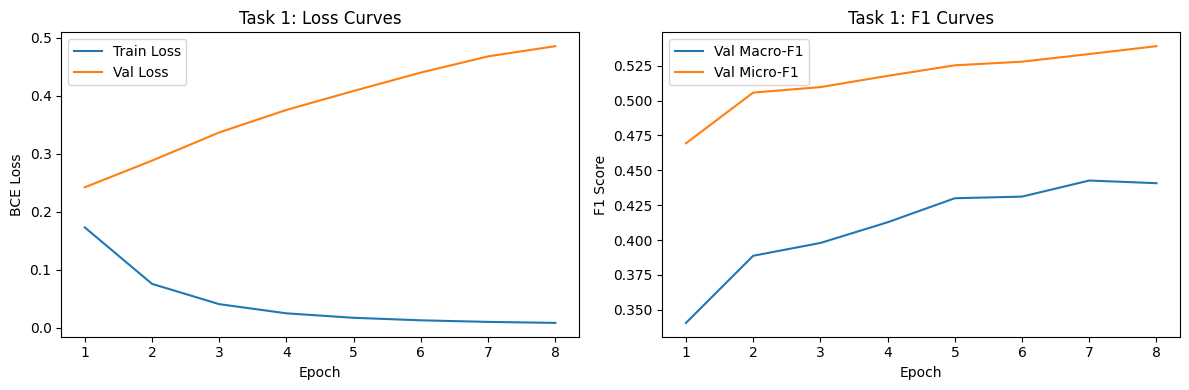

In [24]:
# Cell 24: Plot training curves (for your report)
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Task 1: Loss Curves")
axes[0].legend()

axes[1].plot(epochs_range, history["val_macro_f1"], label="Val Macro-F1")
axes[1].plot(epochs_range, history["val_micro_f1"], label="Val Micro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Task 1: F1 Curves")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/results/task1_curves.png", dpi=150)
plt.show()